# The Time-Zone Case: EWJ

**Why this fund gets its own notebook.** The premium is the same arithmetic for
every fund in the universe — price over NAV, minus one. It is not the same
*quantity*. For a credit fund it measures the cost of assembling a bond
portfolio. For EWJ it measures something else entirely, and reading it the same
way would be the single largest misinterpretation available in this project.

The story here has three turns:

1. EWJ looks anomalous — the widest deviations in the sample, yet no
   day-to-day persistence.
2. The anomaly resolves into a genuine finding: the premium predicts the next
   Tokyo session, and it is not a NAV artefact.
3. The finding does **not** survive as a trading opportunity, for a reason
   that is more interesting than the finding itself.

In [1]:
import sys, warnings, logging
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "configs" / "universe.yaml").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np, pandas as pd, yfinance as yf
import matplotlib.pyplot as plt, matplotlib.dates as mdates
from scipy import stats

from src.config import load_universe
from src.data.loaders import load_prices, load_nav_file
from src.data.align import align_price_nav
from src.analysis.premium import add_premium
from src.analysis.reversion import estimate_reversion
from src.analysis.intraday import profile_intraday
from src.analysis.discovery import measure_price_discovery
from src.viz.style import use_house_style, annotate, PREMIUM, DISCOUNT, SERIES, INK, INK_SECONDARY, INK_MUTED

use_house_style(); warnings.filterwarnings("ignore"); logging.disable(logging.INFO)
u = load_universe(); FUND = u["EWJ"]

frame, _ = align_price_nav(
    load_prices("EWJ", u.start, u.end_or_today),
    load_nav_file(ROOT / "data" / "raw" / "nav" / "EWJ.xls"),
    ticker="EWJ", start=u.start, end=u.end_or_today)
frame = add_premium(frame)
prem = frame["premium_bps"]
print(f"{FUND.ticker} — {FUND.name}")
print(f"underlying market trades in a different session: {FUND.foreign_session}")
print(f"{len(frame):,} aligned days, {frame.index.min():%Y-%m-%d} to {frame.index.max():%Y-%m-%d}")

EWJ — iShares MSCI Japan ETF
underlying market trades in a different session: True
2,185 aligned days, 2018-01-02 to 2026-09-11


---
## 1. The anomaly

Run EWJ through the same pipeline as everything else and two facts sit
uncomfortably together.

In [2]:
r = estimate_reversion(prem, ticker="EWJ")
others = {}
for t in ("IVV", "HYG", "EMB", "LQD"):
    f2, _ = align_price_nav(load_prices(t, u.start, u.end_or_today),
                            load_nav_file(ROOT / "data" / "raw" / "nav" / f"{t}.xls"),
                            ticker=t, start=u.start, end=u.end_or_today)
    others[t] = add_premium(f2)["premium_bps"]

print(f"{'fund':<6}{'sd of premium':>16}{'|prem| > 100bp':>17}{'persistence b':>15}")
print("-" * 56)
for t, s in [("EWJ", prem)] + list(others.items()):
    rr = estimate_reversion(s, ticker=t)
    print(f"{t:<6}{s.std():>13.1f}bps{(s.abs() > 100).mean() * 100:>16.1f}%{rr.fit.b:>15.3f}")
print()
print("EWJ has by far the widest deviations -- and almost no day-to-day memory.")
print("A fund where arbitrage had broken down should show the opposite:")
print("large deviations that PERSIST because nobody can close them.")

fund     sd of premium   |prem| > 100bp  persistence b
--------------------------------------------------------
EWJ            59.4bps             6.9%          0.101
IVV             4.1bps             0.0%          0.095
HYG            30.7bps             1.6%          0.477
EMB            46.9bps             4.9%          0.591
LQD            32.1bps             1.1%          0.629

EWJ has by far the widest deviations -- and almost no day-to-day memory.
A fund where arbitrage had broken down should show the opposite:
large deviations that PERSIST because nobody can close them.


findfont: Failed to find font weight semibold, now using 700.


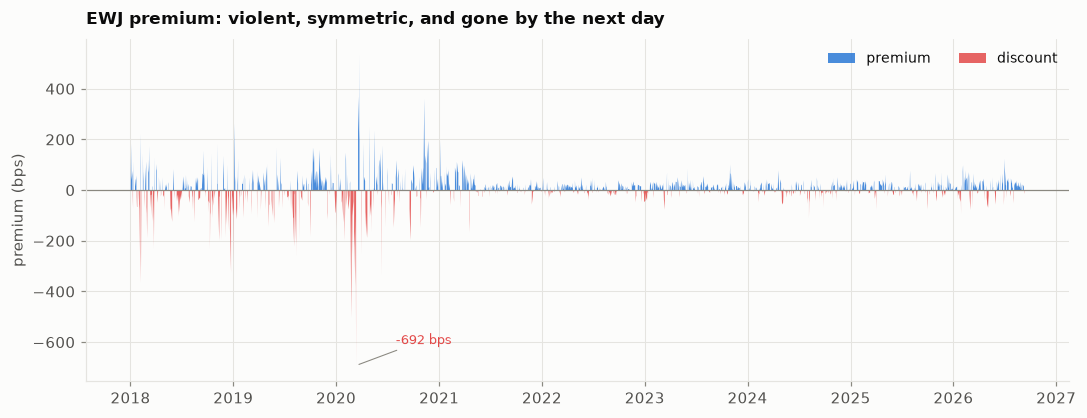

In [3]:
fig, ax = plt.subplots(figsize=(10, 3.9))
ax.fill_between(prem.index, 0, prem.where(prem >= 0), color=PREMIUM, alpha=.85, lw=0, label="premium")
ax.fill_between(prem.index, 0, prem.where(prem < 0), color=DISCOUNT, alpha=.85, lw=0, label="discount")
ax.axhline(0, color=INK_MUTED, lw=.8)
worst = prem.idxmin()
annotate(ax, worst, prem.loc[worst], f"{prem.loc[worst]:,.0f} bps", dx=26, dy=14, color=DISCOUNT)
ax.set_title("EWJ premium: violent, symmetric, and gone by the next day")
ax.set_ylabel("premium (bps)"); ax.legend(loc="upper right", ncol=2)
ax.xaxis.set_major_locator(mdates.YearLocator()); ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout(); plt.show()

The deviations reach ±5% and the series still shows almost no persistence.
Those two facts only fit together if the gap is **closed by something other
than the ETF price moving back**.

That is exactly what a frozen basket does. Tokyo is shut for the entire US
session, so NAV is struck on a stale close and cannot move. Overnight Tokyo
opens, the basket reprices, and the gap disappears — not because the ETF was
wrong, but because NAV caught up.

If that is the mechanism, the premium should **predict** the next Tokyo
session.

---
## 2. Testing it — and the trap that makes the obvious test worthless

The obvious test regresses tomorrow's NAV return on today's premium. It gives
a strong result for EWJ. It is also **not trustworthy**, and the reason is
worth understanding because it applies to a whole class of ETF studies.

$$\text{premium}_t = \frac{P_t}{\text{NAV}_t} - 1
\qquad
\text{navret}_{t+1} = \frac{\text{NAV}_{t+1}}{\text{NAV}_t} - 1$$

Both divide by $\text{NAV}_t$. If NAV carries any measurement error, that
shared denominator manufactures a positive relationship **with no information
involved at all**.

A placebo at $t{+}2$ does not rescue it either: the mechanical effect lives
only at $t{+}1$, so both explanations predict the same decay. That placebo was
run during this project and discarded for exactly this reason.

In [4]:
# A world with NO information whatsoever -- only NAV measurement error.
rng = np.random.default_rng(4)
n = 2000
true_level = 100 * np.exp(np.cumsum(rng.normal(0, 50, n)) / 1e4)
observed_nav = true_level * (1 + rng.normal(0, 60, n) / 1e4)
fake_premium = pd.Series((true_level / observed_nav - 1) * 1e4)
fake_navret = pd.Series(observed_nav).pct_change().shift(-1) * 1e4

d = pd.concat([fake_premium, fake_navret], axis=1).dropna(); d.columns = ["p", "n"]
art = stats.linregress(d["p"], d["n"])
print("Synthetic world containing zero information, only NAV noise:")
print(f"   slope {art.slope:+.3f}   t = {art.slope/art.stderr:.1f}   R^2 = {art.rvalue**2:.3f}")
print()
print("A convincing 'the ETF leads NAV' result, built from nothing at all.")
print("Any test using NAV on both sides is exposed to this.")

Synthetic world containing zero information, only NAV noise:
   slope +1.034   t = 36.1   R^2 = 0.395

A convincing 'the ETF leads NAV' result, built from nothing at all.
Any test using NAV on both sides is exposed to this.


### The test that does work

Use a benchmark computed **outside** the fund's NAV process. The Nikkei 225 is
calculated in Tokyo and shares no input with iShares' valuation, so NAV noise
cannot move it.

In [5]:
def index_series(sym):
    raw = yf.download(sym, start=u.start, end=u.end_or_today, auto_adjust=False, progress=False)
    s = raw["Close"].iloc[:, 0] if raw.columns.nlevels > 1 else raw["Close"]
    s.index = pd.to_datetime(s.index).tz_localize(None).normalize()
    return s

nikkei = index_series("^N225")
disc = measure_price_discovery(prem, nikkei, ticker="EWJ", target_name="Nikkei 225", external=True)
print(disc.summary())
print()
print(f"   slope {disc.slope:+.3f}  ->  a 100bp premium is followed by a {disc.slope*100:.0f}bp Nikkei move")
print(f"   t = {disc.t_stat:.1f},  R^2 = {disc.r_squared:.3f},  n = {disc.n:,}")
print(f"   backward placebo R^2 = {disc.placebo_r_squared:.3f}  (must be near zero)")

EWJ->Nikkei 225: slope +0.92 t=+18.2 R2=0.140 (placebo 0.010) [external] leads the target

   slope +0.919  ->  a 100bp premium is followed by a 92bp Nikkei move
   t = 18.2,  R^2 = 0.140,  n = 2,045
   backward placebo R^2 = 0.010  (must be near zero)


findfont: Failed to find font weight semibold, now using 700.


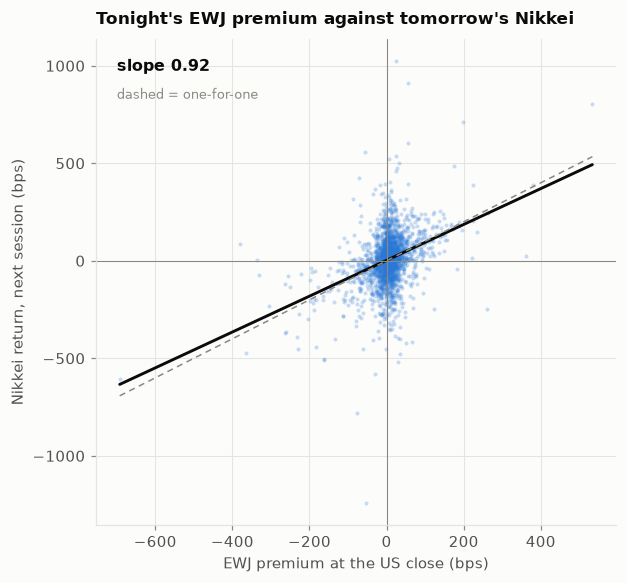

In [6]:
nk_ret = (nikkei.pct_change() * 1e4).shift(-1)
d = pd.concat([prem.rename("prem"), nk_ret.rename("nk")], axis=1).dropna()

fig, ax = plt.subplots(figsize=(5.8, 5.4))
ax.scatter(d["prem"], d["nk"], s=7, color=PREMIUM, alpha=.25, lw=0)
g = np.linspace(d["prem"].min(), d["prem"].max(), 100)
fit = stats.linregress(d["prem"], d["nk"])
ax.plot(g, fit.intercept + fit.slope * g, color=INK, lw=1.9)
ax.plot(g, g, color=INK_MUTED, lw=1.0, ls=(0, (4, 3)))
ax.axhline(0, color=INK_MUTED, lw=.7); ax.axvline(0, color=INK_MUTED, lw=.7)
ax.text(.04, .96, f"slope {fit.slope:.2f}", transform=ax.transAxes, fontsize=10.5,
        color=INK, va="top", fontweight="semibold")
ax.text(.04, .90, "dashed = one-for-one", transform=ax.transAxes, fontsize=8.5,
        color=INK_MUTED, va="top")
ax.set_title("Tonight's EWJ premium against tomorrow's Nikkei")
ax.set_xlabel("EWJ premium at the US close (bps)")
ax.set_ylabel("Nikkei return, next session (bps)")
plt.tight_layout(); plt.show()

The fitted line sits almost on the one-for-one diagonal. The premium is not a
vague directional hint — it is a **calibrated forecast** of the next Tokyo
session.

So EWJ's premium is not mispricing. The ETF is right and NAV is late. Reading
that number as "arbitrage has failed here" would be precisely backwards.

---
## 3. Why it is still not a trading opportunity

A 0.92 slope with $t = 18$ looks like something a desk would want. It is not,
and the reason is the most useful thing in this notebook.

**First:** most of the move happens before anyone could act. Tokyo opens three
hours after the US close, so split the next session at its open.

In [7]:
raw = yf.download("^N225", start=u.start, end=u.end_or_today, auto_adjust=False, progress=False)
nk = raw.xs("^N225", axis=1, level=1) if raw.columns.nlevels > 1 else raw
nk.index = pd.to_datetime(nk.index).tz_localize(None).normalize()

split = pd.DataFrame({"prem": prem}).join(pd.DataFrame({
    "gap": (nk["Open"] / nk["Close"].shift(1) - 1).shift(-1) * 1e4,
    "session": (nk["Close"] / nk["Open"] - 1).shift(-1) * 1e4,
    "total": (nk["Close"] / nk["Close"].shift(1) - 1).shift(-1) * 1e4,
}), how="inner").dropna()

print(f"{'component':<34}{'slope':>9}{'t':>7}{'R^2':>9}")
print("-" * 59)
for c, lbl in [("gap", "opening GAP — untradeable"),
               ("session", "Tokyo session — tradeable"),
               ("total", "full next-day move")]:
    rr = stats.linregress(split["prem"], split[c])
    print(f"  {lbl:<32}{rr.slope:>9.3f}{rr.slope/rr.stderr:>7.1f}{rr.rvalue**2:>9.4f}")

share = stats.linregress(split["prem"], split["gap"]).slope / stats.linregress(split["prem"], split["total"]).slope
print(f"\n  {share:.0%} of the predictable move lands in the opening gap.")

component                             slope      t      R^2
-----------------------------------------------------------
  opening GAP — untradeable           0.652   25.1   0.2357
  Tokyo session — tradeable           0.268    7.1   0.0242
  full next-day move                  0.919   18.2   0.1399

  71% of the predictable move lands in the opening gap.


**Second, and decisively:** CME Nikkei futures trade nearly 24 hours. While
Tokyo cash is shut, the price of Japan risk is still being updated
continuously in Chicago.

If the premium carries information, it should already be in the futures price
at the moment we observe it.

In [8]:
raw = yf.download("NKD=F", start=u.start, end=u.end_or_today, auto_adjust=False, progress=False)
fut = raw.xs("NKD=F", axis=1, level=1) if raw.columns.nlevels > 1 else raw
fut.index = pd.to_datetime(fut.index).tz_localize(None).normalize()
fut_ret = fut["Close"].pct_change() * 1e4

fd = pd.DataFrame({"prem": prem}).join(pd.DataFrame({
    "same": fut_ret, "next": fut_ret.shift(-1)}), how="inner").dropna()

print(f"{'':<44}{'slope':>9}{'t':>7}{'R^2':>9}")
print("-" * 69)
for c, lbl in [("same", "futures move SAME day — already priced?"),
               ("next", "futures move NEXT day — anything left?")]:
    rr = stats.linregress(fd["prem"], fd[c])
    print(f"  {lbl:<42}{rr.slope:>9.3f}{rr.slope/rr.stderr:>7.1f}{rr.rvalue**2:>9.4f}")
print(f"\n  n = {len(fd):,}")

                                                slope      t      R^2
---------------------------------------------------------------------
  futures move SAME day — already priced?       1.031   23.0   0.1945
  futures move NEXT day — anything left?       -0.135   -2.7   0.0034

  n = 2,183


findfont: Failed to find font weight semibold, now using 700.


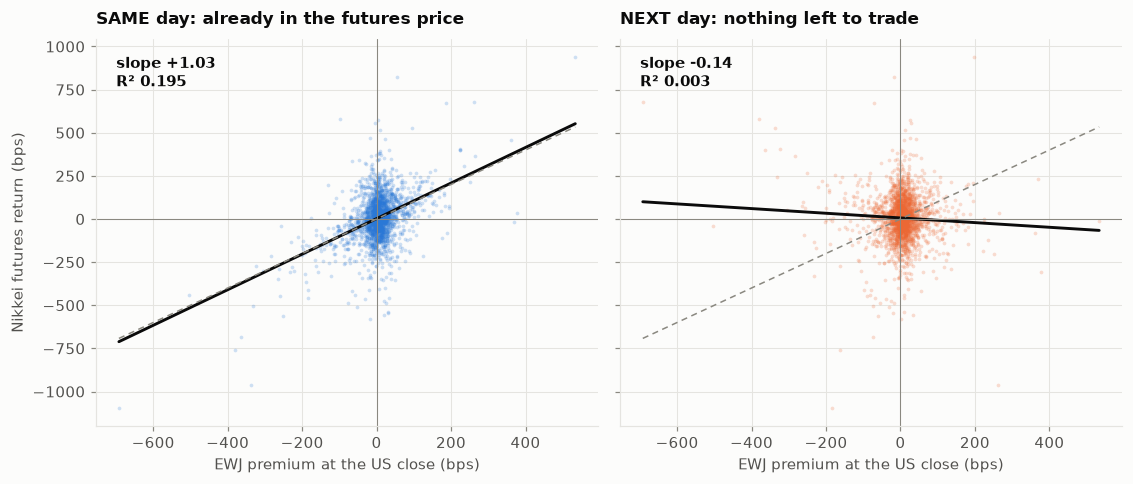

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10.4, 4.5), sharey=True)
for ax, col, ttl, colour in [
    (axes[0], "same", "SAME day: already in the futures price", SERIES[0]),
    (axes[1], "next", "NEXT day: nothing left to trade", SERIES[1]),
]:
    ax.scatter(fd["prem"], fd[col], s=6, color=colour, alpha=.22, lw=0)
    g = np.linspace(fd["prem"].min(), fd["prem"].max(), 100)
    rr = stats.linregress(fd["prem"], fd[col])
    ax.plot(g, rr.intercept + rr.slope * g, color=INK, lw=1.9)
    ax.plot(g, g, color=INK_MUTED, lw=1.0, ls=(0, (4, 3)))
    ax.axhline(0, color=INK_MUTED, lw=.7); ax.axvline(0, color=INK_MUTED, lw=.7)
    ax.set_title(ttl)
    ax.text(.04, .96, f"slope {rr.slope:+.2f}\nR² {rr.rvalue**2:.3f}", transform=ax.transAxes,
            fontsize=10, color=INK, va="top", fontweight="semibold")
    ax.set_xlabel("EWJ premium at the US close (bps)")
axes[0].set_ylabel("Nikkei futures return (bps)")
plt.tight_layout(); plt.show()

That settles it. The premium moves **one-for-one with futures that have
already traded**, and predicts essentially nothing the following day.

So the premium is not a forecast at all. It is a **measurement of how far the
stale Tokyo cash close has drifted from the live market** — and that live
market is quoted continuously, visible to everyone, in futures.

The earlier Nikkei result was real. But the Nikkei **cash index** is the stale
object in that regression. Predicting a stale benchmark is easy and worthless,
for the same reason you can "predict" a mutual fund's NAV from this morning's
market move.

---
## 4. What the intraday data shows

One more piece of evidence, and EWJ is the only fund in the universe where it
is clean. For a domestic fund, a wide intraday price range is ambiguous — the
price may have moved because the basket moved, and NAV is unobserved in
between. For EWJ the basket is genuinely frozen, so the intraday price range
**is** the intraday premium range.

In [10]:
ip = profile_intraday(frame, ticker="EWJ", foreign_session=True)
print(f"   median intraday premium range   {ip.median_range_bps:6.1f} bps")
print(f"   median |premium| at the close   {ip.median_abs_close_bps:6.1f} bps")
print(f"   premium changes sign intraday   {ip.pct_straddling_zero:6.0f}% of days")
print(f"   median retraced before the bell {ip.median_unwound_bps:6.1f} bps")
print()
print("The deviation is not a slow drift that accumulates. It opens and")
print("partly closes within the session, then resets overnight when Tokyo")
print("reprices. Nothing carries over -- which is why the AR(1) finds no")
print("persistence despite the largest deviations in the universe.")

   median intraday premium range     74.0 bps
   median |premium| at the close     18.5 bps
   premium changes sign intraday       67% of days
   median retraced before the bell   44.1 bps

The deviation is not a slow drift that accumulates. It opens and
partly closes within the session, then resets overnight when Tokyo
reprices. Nothing carries over -- which is why the AR(1) finds no
persistence despite the largest deviations in the universe.


---
## 5. What this means for the headline statistic

The premium measures a different thing in each part of the universe, and a
single number cannot be read the same way across them:

| Fund type | What the premium measures | Is it an opportunity? |
|---|---|---|
| Large-cap equity (IVV, SPY, ITOT) | Almost nothing — under 1bp | No: arbitrage closes it before we can observe it |
| Credit (LQD, HYG, EMB) | The cost of assembling the basket | No: it *is* the cost, +10 to +28bps |
| Time-zone (EWJ, EEM) | How stale the home-market close is | No: already quoted in futures |

Three funds, three different reasons, none of them "the market is wrong."

**For the write-up.** The temptation is to report a cross-sectional ordering of
half-lives and let EWJ sit in it as "a slow-reverting fund." That reading is
wrong twice over: EWJ's deviations do not persist at all, and they are not
mispricing. Stating this before anyone asks is worth more than the ordering
itself — it demonstrates that the headline number was understood rather than
merely computed.